# COE 311K Final Project, Part 1
Individual project by Thomas Thomas (tlt2748)

## Introduction and Model Selection

For part 1 of my final proect, I have selected the spring-damper system of the Tesla Cybertruck's suspension. The spring and damper work together to smooth the vertical motion of the vehicle on and off paved roads, including situations like potholes and loose rocks.

The governing 2nd order ODE is:
$$ m\frac{d^2y}{dt^2}+c\frac{dy}{dt}+ky=0 $$


Converted into 2 1st order ODEs using $y_1=y$, $y_2=\frac{dy}{dt}$, the system is:

$$ \frac{dy_1}{dt}=y_2 $$
$$ \frac{dy_2}{dt}=-\frac{c}{m}y_2-\frac{k}{m}y_1 $$


The physical meaning of each variable and parameter is as follows:
- $y_1$: The vertical displacement of the cybertruck.
- $y_2$: The vertical velocity of the cybertruck.
- $m$: The mass of the cybertruck, in $kg$.
- $c$: The damping coefficient, in $\frac{Ns}{m}$.
- $k$: The spring constant, in $\frac{N}{m}$.


## Parameter Research and Justification

Note 1, the mass is given in pounds near the bottom of the page and represents the full vehicle mass (4 times the mass parameter used here).

Note 2, the spring and damper values for the real cybertruck are variable. Values used here are for common vehicles, keeping the cybertruck's slightly heavier mass in mind.

Note 3, the damping coefficient source gives a damping ratio of 0.3, from which the damping coefficient can be calculated using: 

$$ \text{damping coefficient} = \text{damping ratio}\times2\sqrt{\text{spring constant}\times\text{system mass}} $$

Table of parameters:

| Parameter | Value | Units | Source |
| :-: | :-: | :-: | :-: |
| Mass | 778 | $kg$ | [1/4 Cybertruck Mass](https://www.tesla.com/cybertruck) |
| Damping Coefficient | 5900 | $\frac{Ns}{m}$ | [Vehicle Damping Ratio](https://www.researchgate.net/figure/ehicle-typical-damping-coefficient_tbl1_245401813) |
| Spring Constant | 122,600 | $\frac{N}{m}$ | [Toyota Truck Springs](https://accutuneoffroad.com/articles/coilover-spring-rates-for-toyota-tacoma-4runner/?srsltid=AfmBOorxreiVrSBBg12TkP-aGlLbJvSkN3kL4PrmfJuEWoaHAlArwW_a#:~:text=How%20soft%20can%20we%20go,for%20the%20Tacoma%20and%204Runner.) |

The physical scenario I chose to analyze is what happens when the cybertruck lands on the ground after jumping off a 1 meter ledge. The initial conditions are then $y_1=0, y_2=-\sqrt{2gh}=-\sqrt{2\times9.81m/s^2\times1m}=-4.43 m/s$, because the vertical displacement is 0 when the cybertruck initially makes contact with the ground and the negative vertical velocity is calculated from gravity and ledge height.

## Numerical Methods Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

def euler_forward(f, y1_0, y2_0, t0, tf, h):
    # Arrays and initial conditions
    t_vals = np.arange(t0, tf+h, h)
    y1 = np.zeros_like(t_vals)
    y2 = np.zeros_like(t_vals)
    y1[0] = y1_0
    y2[0] = y2_0
    
    # Time marching loop
    for i in range(t_vals.size-1):
        y1[i + 1] = y1[i] + h * y2[i]
        y2[i + 1] = y2[i] + h * f(t_vals[i], y1[i], y2[i])
    
    # Return all values
    return t_vals, y1, y2

def runge_kutta(f, y1_0, y2_0, t0, tf, h):
    # Arrays and initial conditions
    t_vals = np.arange(t0, tf+h, h)
    y1 = np.zeros_like(t_vals)
    y2 = np.zeros_like(t_vals)
    y1[0] = y1_0
    y2[0] = y2_0
    
    # Time marching loop
    for i in range(t_vals.size-1):
        # y1 is the same as Euler Forward
        y1[i + 1] = y1[i] + h * y2[i]
        # Use the weighted average of 4 slopes for y2
        k1 = h * f(t_vals[i], y1[i], y2[i])
        k2 = h * f(t_vals[i] + h/2, (y1[i] + y1[i+1])/2, y2[i] + k1/2)
        k3 = h * f(t_vals[i] + h/2, (y1[i] + y1[i+1])/2, y2[i] + k2/2)
        k4 = h * f(t_vals[i] + h, y1[i+1], y2[i] + k3)
        y2[i + 1] = y2[i] + (k1 + 2*k2 + 2*k3 + k4) / 6
        
    # Return all values
    return t_vals, y1, y2

Each method takes start and end time, step size, initial guesses, and the acceleration function and returns the time, displacement, and velocity arrays.

## Solutions and Comparison

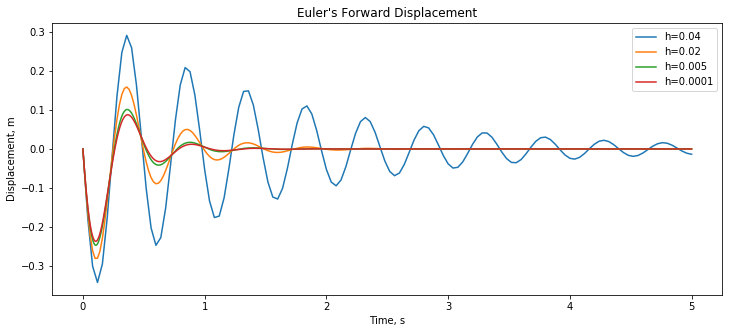

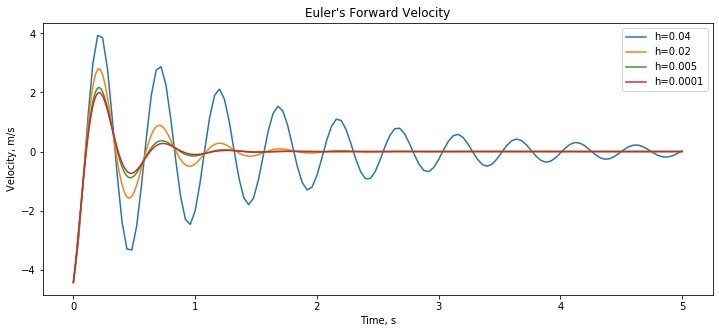

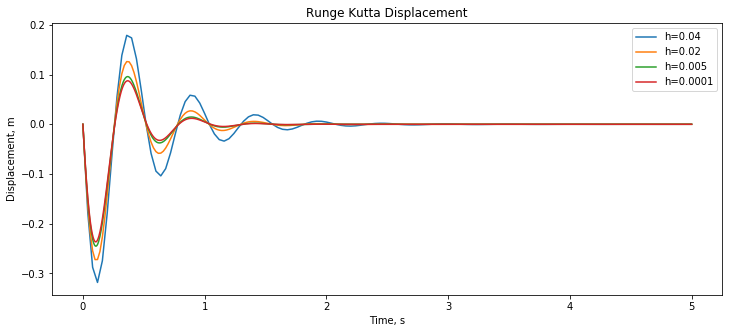

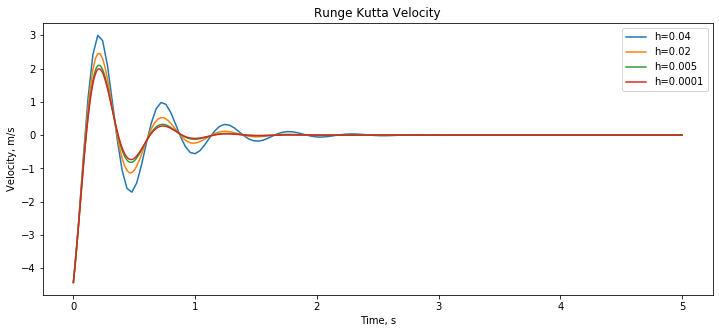

In [2]:
# Physical Parameters
m = 778 # kg
c = 5900 # Ns/m
k = 122600 # N/m

# Acceleration Function
f = lambda t, y1, y2: -(c/m)*y2 - (k/m)*y1

# Initial Conditions
y1_0 = 0 # m
y2_0 = -4.43 # m/s

# Simulation Parameters
h_vals = [0.04, 0.02, 0.005, 0.0001]
t0 = 0 # s
tf = 5 # s

# Calculations
data = [[list(euler_forward(f, y1_0, y2_0, t0, tf, h)), list(runge_kutta(f, y1_0, y2_0, t0, tf, h))] for h in h_vals]
# Array shape:
# 1st index: h value index (0-2) [0.1, 0.03, 0.01]
# 2nd index: Euler's Forward or Runge Kutta (0-1)
# 3rd index: Output arrays (0-2) [t_vals, y1, y2]
# 4th index: Individual data points (Number varies based on h)
# So to get the displacement array from Euler Forward with h=0.03, use: data[1][0][1]

# Plots: comparison of Euler's Forward vs Runge Kutta,
# with displacement and velocity across all step sizes
for method, title in zip([0, 1], ["Euler's Forward", "Runge Kutta"]):
    for output_array in [1, 2]:
        plt.figure(figsize=(12,5))
        for i in range(len(h_vals)):
            plt.plot(data[i][method][0], data[i][method][output_array], label=f"h={h_vals[i]}")
        plt.legend()
        plt.xlabel("Time, s")
        plt.ylabel("Velocity, m/s" if output_array==2 else "Displacement, m")
        plt.title(title + (" Velocity" if output_array==2 else " Displacement"))
        plt.show()

One visual difference between the two methods is that for h=0.04, Runge Kutta does a much better job stabilizing the curve: Euler's Forward stabilizes well after 10 seconds, while Runge Kutta stabilizes around 2.5 seconds.

Another visual difference between the methods is the extreme step sizes (h=0.04, 0.0005) are closer together for Runge Kutta than they are for Euler's Forward, as seen on the y-axis limits for each graph.

## Stability Analysis

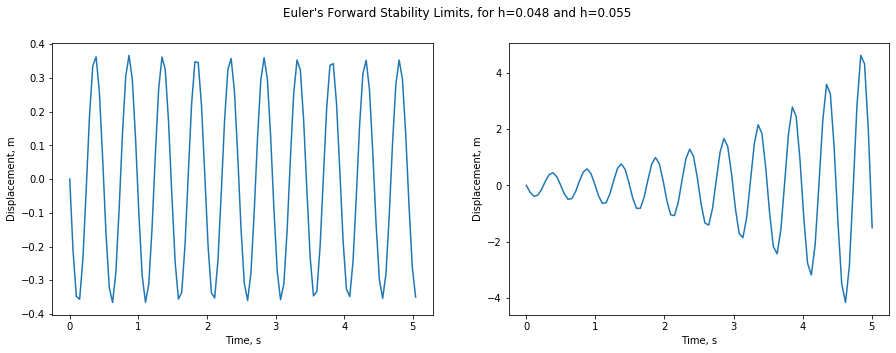

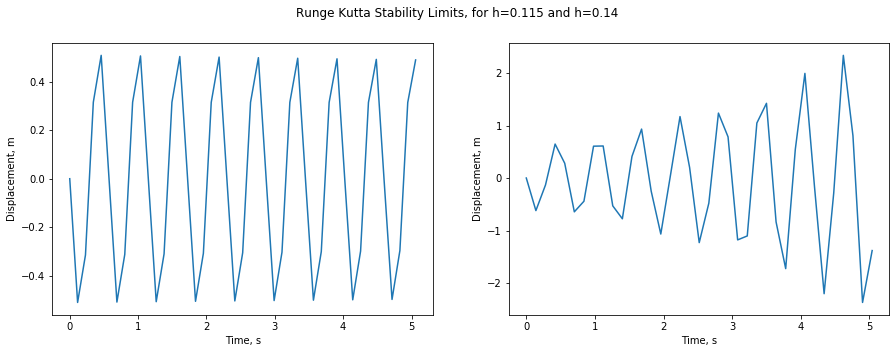

In [3]:
# Re-selection of step sizes to demonstrate stability limits
h_vals2 = [0.048, 0.055, 0.115, 0.14]
data2 = [[list(euler_forward(f, y1_0, y2_0, t0, tf, h)), list(runge_kutta(f, y1_0, y2_0, t0, tf, h))] for h in h_vals2]

# Plot stability limit demonstration
for method, title in zip([0, 1], ["Euler's Forward", "Runge Kutta"]):
    plt.figure(figsize=(15, 5))
    for i in [1, 2]:
        plt.subplot(1, 2, i)
        h = i-1 + 2*method
        plt.plot(data2[h][method][0], data2[h][method][1])
        plt.xlabel("Time, s")
        plt.ylabel("Displacement, m")
    plt.suptitle(title + f" Stability Limits, for h={h_vals2[2*method]} and h={h_vals2[2*method + 1]}")
    plt.show()

The maximum stable step sizes for each method are shown here: 0.048 for Euler's Forward and 0.115 for Runge Kutta. Beyond this, both methods diverge. In this physical model's case, stable means the amplitude of the oscillation decreases over time, while unstable means the amplitude increases over time.

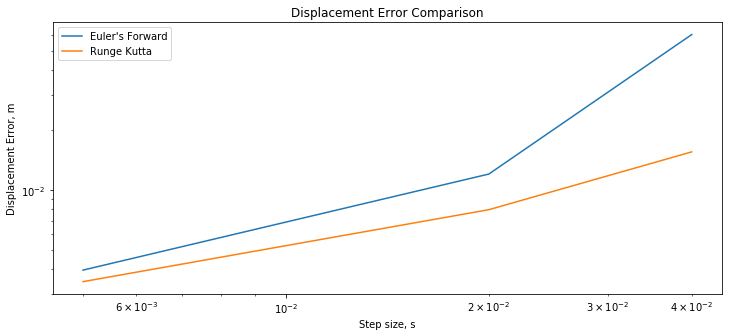

In [4]:
# Plot mean error vs. original step sizes, using Runge Kutta h=0.0001 as truth
truth = lambda t: np.array(data[3][1])[:,np.argmax(data[3][1][0] == t)]

mean_error = np.array([[[np.mean(np.abs(np.array(data[h][method][output_array]) \
                               - np.array([truth(t)[output_array] for t in data[h][method][0]]) \
                                )) for output_array in [1, 2]] for method in [0, 1]] for h in range(3)])

plt.figure(figsize=(12,5))
plt.plot(h_vals[:-1], mean_error[:,0,0], label="Euler's Forward")
plt.plot(h_vals[:-1], mean_error[:,1,0], label="Runge Kutta")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Step size, s")
plt.ylabel("Displacement Error, m")
plt.legend()
plt.title("Displacement Error Comparison")
plt.show()

## Conclusions

The Runge Kutta method performed better for my application because it is able to stabilize step sizes twice as large as Euler's Forward and it is closer to the real solution than Euler's Forward at a given step size. However, it also takes longer to compute, on the order of O(h^4) instead of O(h).

Overall, I would suggest Euler's Forward method for this problem because the time scale is small enough and the scale of the error is small enough to get the displacement of the cybertruck over time within a millimeter of the right answer in just a few seconds of calculation. Lesson learned: Sometimes the simplest approach is the best one.